# Model interpretation

This notebook explains the selected logistic regression model using the same held-out test set defined in the previous notebooks.

The goal is not only to measure performance, but also to identify the customer characteristics most associated with churn risk.

In [1]:
from pathlib import Path

REPORTS_DIRECTORY = Path("../reports/figures")
REPORTS_DIRECTORY.mkdir(parents=True, exist_ok=True)

import pandas as pd
from sklearn.model_selection import train_test_split

DATA_PATH = Path("../data/raw/telco_customer_churn.csv")

df = pd.read_csv(DATA_PATH)

TARGET = "Churn"
ID_COLUMN = "customerID"

feature_columns = [
    column
    for column in df.columns
    if column not in [TARGET, ID_COLUMN]
]

X = df[feature_columns].copy()
y = df[TARGET].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

Training rows: 5634
Test rows: 1409


## Recreate the selected model

The logistic regression pipeline is rebuilt using the same preprocessing decisions and reproducible train/test split used during model selection.

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def clean_total_charges(frame: pd.DataFrame) -> pd.DataFrame:
    """Convert TotalCharges from raw text to numeric values."""

    cleaned = frame.copy()
    cleaned["TotalCharges"] = pd.to_numeric(
        cleaned["TotalCharges"],
        errors="coerce",
    )
    return cleaned


X_train = clean_total_charges(X_train)
X_test = clean_total_charges(X_test)

numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
]

categorical_features = [
    column
    for column in feature_columns
    if column not in numeric_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "one_hot_encoder",
                        OneHotEncoder(handle_unknown="ignore"),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

selected_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1_000,
                random_state=42,
            ),
        ),
    ]
)

selected_model.fit(X_train, y_train)

print("Logistic regression pipeline fitted.")

Logistic regression pipeline fitted.


## Confusion matrix

The confusion matrix separates correct predictions from errors. In churn modelling, false negatives are particularly important: they represent customers predicted to stay who actually churn.

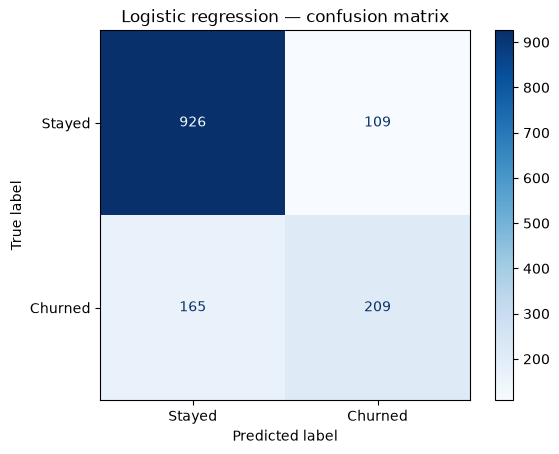

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

y_test_prediction = selected_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_prediction,
    display_labels=["Stayed", "Churned"],
    cmap="Blues",
)

plt.title("Logistic regression — confusion matrix")
plt.savefig(REPORTS_DIRECTORY / "confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

## Global feature importance

Permutation importance estimates how much the model depends on each original input variable. A larger decrease in ROC-AUC after shuffling a feature indicates greater predictive importance.

Feature importance describes associations learned by the model; it does not prove that a variable causes churn.

In [4]:
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    selected_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

feature_importance = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": permutation_result.importances_mean,
        "importance_std": permutation_result.importances_std,
    }
).sort_values(
    "importance_mean",
    ascending=False,
)

feature_importance.head(10)

,feature,importance_mean,importance_std
4,tenure,0.168204,0.008157
7,InternetService,0.038680,0.006325
14,Contract,0.035235,0.003932
17,MonthlyCharges,0.031136,0.004903
18,TotalCharges,0.013411,0.003083
8,OnlineSecurity,0.003664,0.001514
13,StreamingMovies,0.003520,0.001598
12,StreamingTV,0.003422,0.002341
11,TechSupport,0.003241,0.001623
16,PaymentMethod,0.003019,0.001527


## Visualize the main churn drivers

The chart shows the ten original customer variables with the greatest impact on the model's ROC-AUC. Error bars represent variation across repeated permutations.

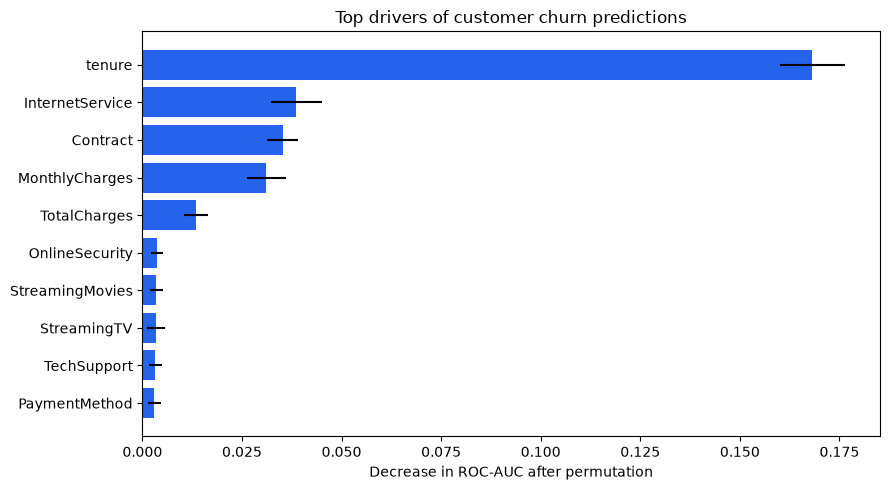

In [5]:
top_features = (
    feature_importance
    .head(10)
    .sort_values("importance_mean")
)

plt.figure(figsize=(9, 5))

plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"],
    color="#2563EB",
)

plt.xlabel("Decrease in ROC-AUC after permutation")
plt.title("Top drivers of customer churn predictions")
plt.tight_layout()
plt.savefig(REPORTS_DIRECTORY / "permutation_importance.png", dpi=200, bbox_inches="tight")
plt.show()

## Local explanations with SHAP

SHAP assigns a contribution to each transformed feature for each prediction. Positive values push the prediction towards churn, while negative values push it towards staying.

These explanations describe the model's behaviour, not causal effects.

In [6]:
import shap

fitted_preprocessor = selected_model.named_steps["preprocessor"]
fitted_classifier = selected_model.named_steps["classifier"]

X_train_transformed = fitted_preprocessor.transform(X_train)
X_test_transformed = fitted_preprocessor.transform(X_test)

transformed_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

explainer = shap.Explainer(
    fitted_classifier,
    X_train_transformed,
    feature_names=transformed_feature_names,
)

shap_values = explainer(X_test_transformed)

print(f"Explained test customers: {shap_values.shape[0]}")
print(f"Transformed features: {shap_values.shape[1]}")

c:\Users\larti\Documents\Codex\2026-09-23\quiero\outputs\customer-churn-ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


Explained test customers: 1409
Transformed features: 46


## SHAP global importance

Mean absolute SHAP values summarize which transformed model inputs have the largest average influence on churn predictions across the test set.

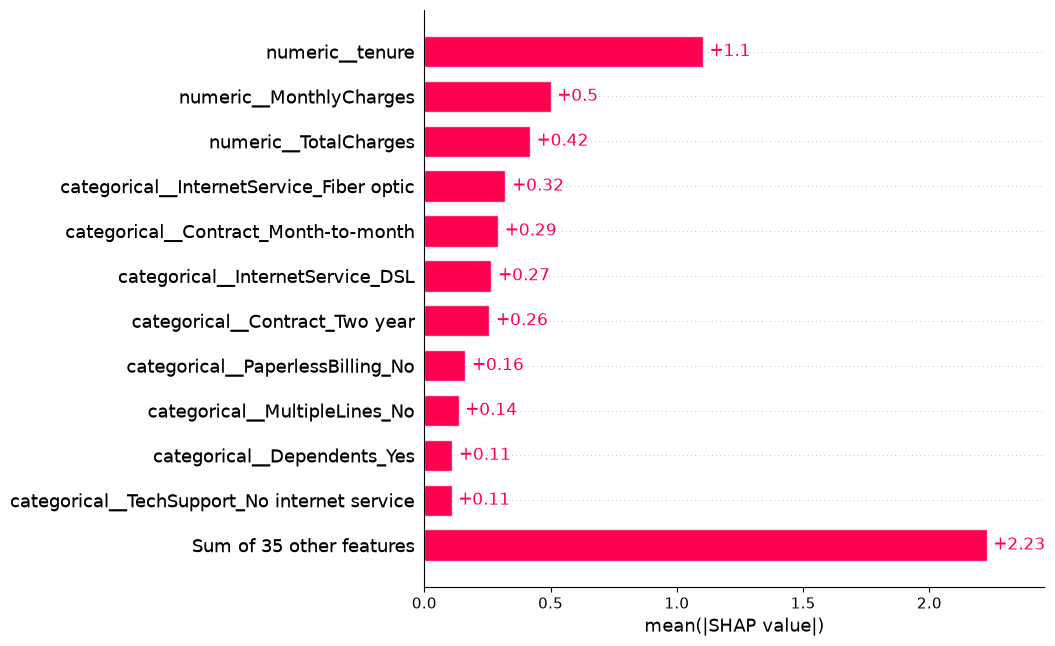

In [7]:
shap_axes = shap.plots.bar(
    shap_values,
    max_display=12,
    show=False,
)
shap_axes.figure.savefig(
    REPORTS_DIRECTORY / "shap_global_importance.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## Direction of feature effects

The SHAP beeswarm plot shows both importance and direction. Each point represents a customer: positive SHAP values increase predicted churn risk, while negative values decrease it.

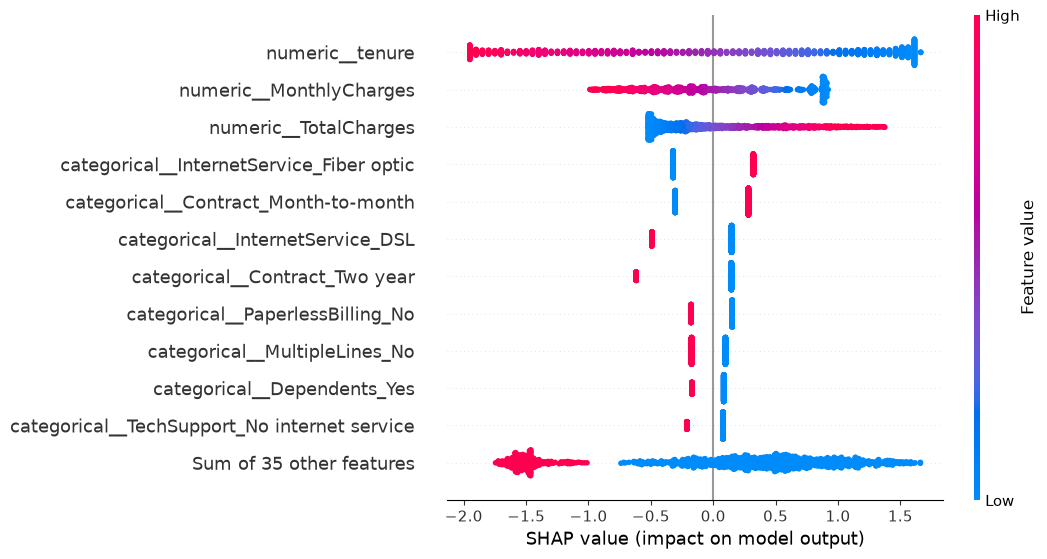

In [8]:
shap_axes = shap.plots.beeswarm(
    shap_values,
    max_display=12,
    show=False,
)
shap_axes.figure.savefig(
    REPORTS_DIRECTORY / "shap_beeswarm.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## Individual high-risk customer explanation

This example explains the test customer with the highest predicted churn probability. It illustrates how individual feature contributions combine to produce a model prediction.

Test customer row: 3380
Predicted churn probability: 85.5%
Observed churn: Yes


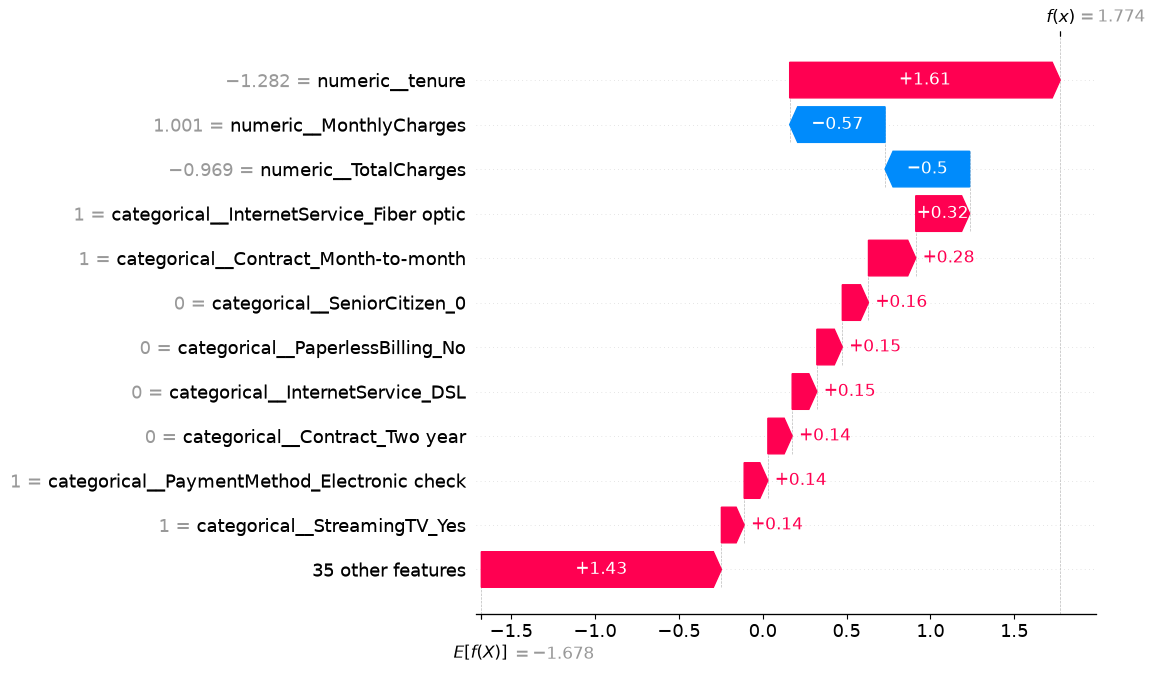

In [9]:
y_test_probability = selected_model.predict_proba(X_test)[:, 1]

highest_risk_position = int(y_test_probability.argmax())
highest_risk_customer = X_test.iloc[highest_risk_position]

print(
    f"Test customer row: {highest_risk_customer.name}"
)
print(
    f"Predicted churn probability: "
    f"{y_test_probability[highest_risk_position]:.1%}"
)
print(
    f"Observed churn: {'Yes' if y_test.iloc[highest_risk_position] == 1 else 'No'}"
)

shap_axes = shap.plots.waterfall(
    shap_values[highest_risk_position],
    max_display=12,
    show=False,
)
shap_axes.figure.savefig(
    REPORTS_DIRECTORY / "shap_high_risk_customer.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## Interpretation takeaway

The global and individual explanations consistently show that customer tenure, contract type, internet service and billing-related characteristics are influential inputs to churn predictions.

For the high-risk example, low tenure, fiber-optic service and a month-to-month contract increase predicted churn risk substantially. These findings can guide retention prioritization, while recognising that model explanations describe predictive associations rather than causal effects.